In [1]:
# Path + packaging
import sys  # no installation needed
from pathlib import Path  # no installation needed

SRC_DIR = Path(r"C:\Users\quantbase\Desktop\SyStrat\src")
PKG_DIR = SRC_DIR / "syslib"
PKG_DIR.mkdir(parents=True, exist_ok=True)
(PKG_DIR / "__init__.py").touch(exist_ok=True)  # ensure it's importable

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("sys.path OK:", SRC_DIR in map(Path, map(str, sys.path)))


sys.path OK: True


In [2]:
from pathlib import Path
import importlib, pandas as pd
import syslib.regimes as R
import numpy as np
import datetime as date
from datetime import date
import syslib.wp_core as wp_core 

importlib.reload(R)

<module 'syslib.regimes' from 'C:\\Users\\quantbase\\Desktop\\SyStrat\\src\\syslib\\regimes.py'>

In [3]:
#---------Regimes------------

In [3]:
RUN_DATE = date.today().strftime("%d-%m-%Y") #"08-12-2025"
BASE = Path(r"C:\Users\quantbase\Desktop\SyStrat") / RUN_DATE
FIGDIR = BASE / "figures"
FIGDIR.mkdir(parents=True, exist_ok=True)

In [4]:
k = 10

Xy = pd.read_parquet(BASE / "data_int/ml/features_raw_long.parquet").sort_values(["ticker","date"]).reset_index(drop=True)

In [5]:
# 40/35/25 per-ticker split (same as your pipeline)
rows_test = []
for tkr, g in Xy.groupby("ticker", sort=True):
    n = len(g)
    i1 = int(np.floor(0.40*n))
    i2 = i1 + int(np.floor(0.35*n))
    g_te = g.iloc[i2:].copy()                 # TEST+VAL rows = i2:
    rows_test.append(g_te[["date","ticker"]]) # contains date & ticker

In [6]:
rowmap_test = pd.concat(rows_test, ignore_index=True)
rowmap_test.to_parquet(BASE / "data_int/ml/rowmap_test_k10.parquet")
rowmap_test.to_csv(BASE / "data_int/ml/rowmap_test_k10.csv")

In [7]:
print("Saved:", BASE / "data_int/ml/rowmap_test_k10.parquet")
print("Saved:", BASE / "data_int/ml/rowmap_test_k10.csv")

Saved: C:\Users\quantbase\Desktop\SyStrat\17-12-2025\data_int\ml\rowmap_test_k10.parquet
Saved: C:\Users\quantbase\Desktop\SyStrat\17-12-2025\data_int\ml\rowmap_test_k10.csv


In [8]:
# If you changed K to 20, make sure your cfg and rowmap are k=20
cfg = R.RegimeConfig(
    base_dir=BASE,
    tickers=("BTC-USD","ETH-USD","BNB-USD","XRP-USD","ADA-USD","LINK-USD","SOL-USD"),
    k_label=10, model_tag="xgb",
    vwap_lookback=60, ema_fast=9, ema_slow=21,
    vol_qtiles=(0.33, 0.66),
    ml_provider_kwargs={
        "x_test_path": BASE / "data_int/ml/rowmap_test_k10.parquet",  # make sure this exists for k=20
        "x_date_col": "date",
        "x_ticker_col": "ticker",
        # optional: "pred_model_col": "pred_en",
    },
)

In [9]:
feat = R.build_regime_features(cfg)

In [10]:
path = R.save_regime_features(cfg, feat)
print("Saved ->", path)

Saved -> C:\Users\quantbase\Desktop\SyStrat\17-12-2025\data_int\regimes\regime_features_k10.parquet


In [11]:
feat.to_csv(Path(r"C:\Users\quantbase\Desktop\SyStrat\17-12-2025\data_int\regimes\regime_features_k10.csv"))

In [12]:
display(feat.groupby(level="ticker").head(2))
display(feat.groupby(level="ticker").tail(2))
print("σ̂ coverage:", feat["sigma_hat"].groupby(level="ticker").apply(lambda s: s.notna().mean()).round(3))
print("vol_tercile value counts:", feat["vol_tercile"].dropna().astype(int).value_counts().sort_index().to_dict())

price        volume  sigma_hat  vol_tercile  \
date       ticker                                                         
2025-11-17 ADA-USD       0.465532    1209943614   0.043404         <NA>   
           BNB-USD     906.482422    3757441490   0.033851         <NA>   
           BTC-USD   92093.875000   94186165724   0.040126         <NA>   
           ETH-USD    3024.538818   41026793235   0.043620         <NA>   
           LINK-USD     13.306071     865194247   0.043042         <NA>   
           SOL-USD     130.848267    7330608944   0.046214         <NA>   
           XRP-USD       2.162098    6068395312   0.040855         <NA>   
2025-11-18 ADA-USD       0.474980    1101225671   0.043346            0   
           BNB-USD     932.482361    3623344375   0.034841            2   
           BTC-USD   92948.875000  101333569062   0.040953            2   
           ETH-USD    3122.979004   41581494270   0.044274            2   
           LINK-USD     13.794932     825409520   0.042886            0   
           SOL-USD     140.714386    7400753648   0.047240            2   
           XRP-USD       2.216479    5793233516   0.039096            0   

                         ema_fast      ema_slow  ema_slope     vwap_roll  \
date       ticker                                                          
2025-11-17 ADA-USD       0.465532      0.465532   0.000000      0.465532   
           BNB-USD     906.482422    906.482422   0.000000    906.482422   
           BTC-USD   92093.875000  92093.875000   0.000000  92093.875000   
           ETH-USD    3024.538818   3024.538818   0.000000   3024.538818   
           LINK-USD     13.306071     13.306071   0.000000     13.306071   
           SOL-USD     130.848267    130.848267   0.000000    130.848267   
           XRP-USD       2.162098      2.162098   0.000000      2.162098   
2025-11-18 ADA-USD       0.467422      0.466391   0.001031      0.465842   
           BNB-USD     911.682410    908.846053   2.836357    907.334879   
           BTC-USD   92264.875000  92171.602273  93.272727  92121.907787   
           ETH-USD    3044.226855   3033.487926  10.738929   3027.766365   
           LINK-USD     13.403843     13.350513   0.053330     13.322100   
           SOL-USD     132.821490    131.745187   1.076304    131.171746   
           XRP-USD       2.172974      2.167042   0.005932      2.163881   

                     vwap_z  
date       ticker            
2025-11-17 ADA-USD      NaN  
           BNB-USD      NaN  
           BTC-USD      NaN  
           ETH-USD      NaN  
           LINK-USD     NaN  
           SOL-USD      NaN  
           XRP-USD      NaN  
2025-11-18 ADA-USD      NaN  
           BNB-USD      NaN  
           BTC-USD      NaN  
           ETH-USD      NaN  
           LINK-USD     NaN  
           SOL-USD      NaN  
           XRP-USD      NaN

price       volume  sigma_hat  vol_tercile  \
date       ticker                                                        
2025-12-15 ADA-USD       0.388091    668504094        NaN            1   
           BNB-USD     858.545105   2222157806        NaN            1   
           BTC-USD   86419.781250  45559514323        NaN            1   
           ETH-USD    2964.183105  28765976892        NaN            1   
           LINK-USD     12.864612    667123756        NaN            1   
           SOL-USD     127.757118   5120043768        NaN            1   
           XRP-USD       1.898673   3479993806        NaN            1   
2025-12-17 ADA-USD       0.384867    520524672        NaN            1   
           BNB-USD     866.127502   2368990464        NaN            1   
           BTC-USD   87423.015625  40572784640        NaN            1   
           ETH-USD    2954.874268  21477345280        NaN            1   
           LINK-USD     12.872709    532660192        NaN            1   
           SOL-USD     129.185120   3773104896        NaN            1   
           XRP-USD       1.930170   2867763456        NaN            1   

                         ema_fast      ema_slow   ema_slope     vwap_roll  \
date       ticker                                                           
2025-12-15 ADA-USD       0.413830      0.423675   -0.009845      0.430678   
           BNB-USD     882.158799    884.778259   -2.619460    880.613329   
           BTC-USD   89609.421628  90115.011347 -505.589720  89795.424745   
           ETH-USD    3094.937566   3076.000539   18.937027   3021.635562   
           LINK-USD     13.550576     13.536320    0.014255     13.381718   
           SOL-USD     132.465909    133.747365   -1.281456    134.941985   
           XRP-USD       2.010275      2.059279   -0.049004      2.092438   
2025-12-17 ADA-USD       0.408037      0.420147   -0.012110      0.429647   
           BNB-USD     878.952540    883.082736   -4.130196    880.116686   
           BTC-USD   89172.140427  89870.284463 -698.144036  89747.168359   
           ETH-USD    3066.924906   3064.989059    1.935846   3019.821495   
           LINK-USD     13.415002     13.475992   -0.060990     13.368167   
           SOL-USD     131.809751    133.332615   -1.522864    134.797543   
           XRP-USD       1.994254      2.047542   -0.053288      2.088511   

                       vwap_z  
date       ticker              
2025-12-15 ADA-USD  -0.907051  
           BNB-USD  -0.387742  
           BTC-USD  -0.892789  
           ETH-USD  -0.557484  
           LINK-USD -0.969825  
           SOL-USD  -1.699280  
           XRP-USD  -1.772964  
2025-12-17 ADA-USD  -0.969060  
           BNB-USD  -0.100257  
           BTC-USD  -0.493713  
           ETH-USD  -0.595485  
           LINK-USD -0.907103  
           SOL-USD  -1.331573  
           XRP-USD  -1.289280

σ̂ coverage: ticker
ADA-USD     0.633
BNB-USD     0.633
BTC-USD     0.633
ETH-USD     0.633
LINK-USD    0.633
SOL-USD     0.633
XRP-USD     0.633
Name: sigma_hat, dtype: float64
vol_tercile value counts: {0: 80, 1: 88, 2: 35}


In [13]:
# 1) Load features from Step 1, or rebuild if needed:
feat_path = BASE / "data_int/regimes" / f"regime_features_k{cfg.k_label}.parquet"
if feat_path.exists():
    feat = pd.read_parquet(feat_path)
else:
    feat = R.build_regime_features(cfg)
    R.save_regime_features(cfg, feat)

In [14]:
# 2) Label (portfolio-level with hysteresis)
labels, daily_state = R.label_regimes_tier1(
    feat, ema_thresh=0.0, vwap_hi=-0.5, vwap_lo=-1.0, hysteresis_days=3
)

In [15]:
p_labels, p_daily = R.save_tier1_labels(cfg, labels, daily_state)
print("Saved labels ->", p_labels, "\nSaved daily ->", p_daily)

Saved labels -> C:\Users\quantbase\Desktop\SyStrat\17-12-2025\data_int\regimes\tier1_labels_k10.parquet 
Saved daily -> C:\Users\quantbase\Desktop\SyStrat\17-12-2025\data_int\regimes\tier1_daily_state_k10.parquet


In [16]:
labels = pd.read_parquet(Path(r"C:\Users\quantbase\Desktop\SyStrat\17-12-2025\data_int\regimes\tier1_labels_k10.parquet"))
daily = pd.read_parquet(Path(r"C:\Users\quantbase\Desktop\SyStrat\17-12-2025\data_int\regimes\tier1_daily_state_k10.parquet"))

In [17]:
labels.to_csv(Path(r"C:\Users\quantbase\Desktop\SyStrat\17-12-2025\data_int\regimes\tier1_labels_k10.csv"))
daily_state.to_csv(Path(r"C:\Users\quantbase\Desktop\SyStrat\17-12-2025\data_int\regimes\tier1_daily_state_k10.csv"))

In [18]:
P = R.estimate_transitions(daily_state, smoothing=0.5)
pP = R.save_transitions(cfg, P)
print("Saved transitions ->", pP)
display(P)

Saved transitions -> C:\Users\quantbase\Desktop\SyStrat\17-12-2025\data_int\regimes\tier1_transitions_k10.csv


,risk_off,neutral,risk_on
risk_off,0.647059,0.176471,0.176471
neutral,0.230769,0.692308,0.076923
risk_on,0.081081,0.027027,0.891892


In [19]:
#-----Visualise

In [20]:
import matplotlib.pyplot as plt

In [21]:
P = pd.read_csv(BASE / "data_int" / "regimes" / "tier1_transitions_k10.csv", index_col=0)

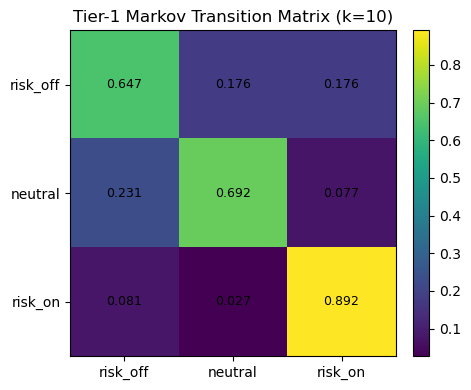

In [22]:
# --- Heatmap of transition matrix ---
plt.figure(figsize=(5,4))
im = plt.imshow(P.values, aspect='equal')
plt.title("Tier-1 Markov Transition Matrix (k=10)")
plt.xticks(range(len(P.columns)), P.columns, rotation=0)
plt.yticks(range(len(P.index)), P.index)
for i in range(P.shape[0]):
    for j in range(P.shape[1]):
        plt.text(j, i, f"{P.values[i,j]:.3f}", ha='center', va='center', fontsize=9)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(FIGDIR / "P_heatmap_k10.png", dpi=150)
plt.show()

In [23]:
# --- Stationary distribution (left eigenvector of P) ---
w, v = np.linalg.eig(P.values.T)
pi = np.real(v[:, np.isclose(w, 1)].flatten())
pi = pi / pi.sum()
pi = pd.Series(pi, index=P.index, name="stationary_prob")
print("Stationary distribution:\n", pi.round(3))

Stationary distribution:
 risk_off    0.254
neutral     0.194
risk_on     0.552
Name: stationary_prob, dtype: float64


In [24]:
# --- Expected duration in each state (E[D] = 1 / (1 - P_ii)) ---
exp_dur = 1.0 / (1.0 - np.diag(P.values))
exp_dur = pd.Series(exp_dur, index=P.index, name="E[duration]")
print("\nExpected durations (days):\n", exp_dur.round(2))


Expected durations (days):
 risk_off    2.83
neutral     3.25
risk_on     9.25
Name: E[duration], dtype: float64


In [25]:
#-----Current Regime

In [26]:
daily_path = BASE / "data_int" / "regimes" / "tier1_daily_state_k10.parquet"

In [38]:
daily_state = pd.read_parquet(daily_path)["state"]
print("Last date:", daily_state.index.max())
print("Current regime:", daily_state.iloc[-1])
display(daily_state.tail(20).to_frame())

Last date: 2025-12-17 00:00:00
Current regime: risk_off


,state
date,
2025-11-27,risk_off
2025-11-28,risk_off
2025-11-29,risk_on
2025-11-30,risk_on
2025-12-01,risk_on
2025-12-02,risk_on
2025-12-03,risk_on
2025-12-04,risk_on
2025-12-05,risk_on


In [29]:
#-----Semi Markov-----

In [30]:
import syslib.semi_markov as SM

In [31]:
daily = pd.read_parquet(BASE / "data_int" / "regimes" / "tier1_daily_state_k10.parquet")["state"]

In [32]:
runs = SM.runs_with_age(daily)
durations = {}
for s, L in runs:
    durations.setdefault(s, []).append(L)

haz_df = []
for s, arr in durations.items():
    arr = np.array(arr, dtype=int)
    maxA = arr.max()
    # survivors at age a: count(L >= a), exits at age a: count(L == a)
    surv = np.array([(arr >= a).sum() for a in range(1, maxA+1)], dtype=float)
    exits = np.array([(arr == a).sum() for a in range(1, maxA+1)], dtype=float)
    haz = np.divide(exits, surv, out=np.zeros_like(exits), where=surv>0)
    haz_df.append(pd.DataFrame({"age": np.arange(1, maxA+1), "hazard": haz, "state": s}))
haz_df = pd.concat(haz_df, ignore_index=True)

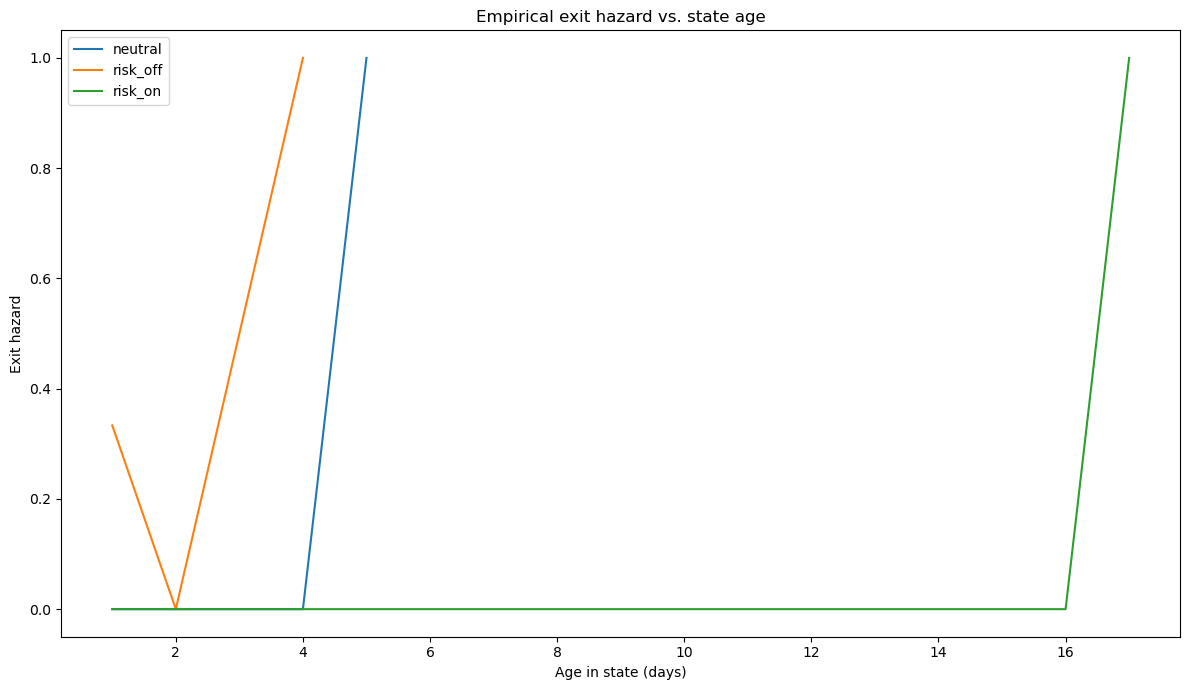


Expected durations (days):



In [33]:
# quick visual
plt.figure(figsize=(12,7))
for s, g in haz_df.groupby("state"):
    plt.plot(g["age"], g["hazard"], label=s)
plt.title("Empirical exit hazard vs. state age")
plt.xlabel("Age in state (days)")
plt.ylabel("Exit hazard")
plt.legend()
plt.tight_layout()
plt.savefig(BASE / "figures" / "semi_markov_hazard_k10.png", dpi=150)
plt.show()

#------Markov
print("\nExpected durations (days):\n")

In [34]:
# 1) Load daily state and transitions
daily = SM.load_daily_state(BASE, k)
P = SM.load_P(BASE, k)

In [35]:
# 2) Hazards (estimate → smooth → save + plot)
H = SM.estimate_hazards(daily)
Hs = SM.smooth_hazards(H, window=3, cap=0.99)
csvp = SM.save_hazards_csv(BASE, k, Hs)
SM.save_hazards_plot(Hs, BASE / "figures" / f"semi_markov_hazard_k{k}.png")
print("Hazards saved to:", csvp)

Hazards saved to: C:\Users\quantbase\Desktop\SyStrat\17-12-2025\data_int\regimes\semi_markov_hazards_k10.csv


In [36]:
# 3) “What regime now?” + semi-Markov soft nowcast
age_series = SM.state_age(daily)
cur_state = daily.iloc[-1]
cur_age = int(age_series.iloc[-1])

In [37]:
soft = SM.nowcast_soft_probs(cur_state, cur_age, P, Hs)
print("Last date:", daily.index.max())
print("Current state / age:", cur_state, cur_age)
print("Semi-Markov nowcast (soft probs):\n", soft.round(3))

Last date: 2025-12-17 00:00:00
Current state / age: risk_off 1
Semi-Markov nowcast (soft probs):
 risk_off    0.667
neutral     0.167
risk_on     0.167
dtype: float64
